# MixedFreqLSTM v1 Analysis

Notebook for comparing encoder architectures (autoregressive vs pre_attn unidir/bidir) across ST and MT on econ-only data, vintages 2019-07 → 2021-06, nobias + N=2 forward-walk + last-1 val_loss_y selection.

Cells are grouped by experiment. Helpers at the top so each experiment block is 3–5 cells.

## Setup

In [9]:
import os
os.environ["RAY_TRAIN_V2_ENABLED"] = "1"
os.environ["TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S"] = "0"
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from functools import partial
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ray
import ray.tune
from sklearn.metrics import mean_squared_error

from train_vintage import train_model
from evaluate_vintage import evaluate_one_vintage_ST, evaluate_one_vintage_MT

ray.init(log_to_driver=False, logging_level="ERROR", ignore_reinit_error=True)

RAY_RESULTS = Path("ray_results").resolve()
OUTPUT_DIR = Path("notebooks/analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "nowcasts"
CACHE_DIR.mkdir(exist_ok=True)

In [10]:
VINTAGES_V1 = pd.date_range(start="2019-07-31", end="2021-06-30", freq="ME")

# Vintages whose held-out last-1 target falls in a COVID shock quarter (Q1/Q2/Q3 2020).
# Derived from the MT-E v1 val_loss_y bimodality and the target_release_lag timing.
SHOCK_VINTAGES = {"2020-05", "2020-06", "2020-07", "2020-08", "2020-09",
                  "2020-10", "2020-11", "2020-12", "2021-01", "2021-03"}

DFM_BASELINE_CSV = "Results/DFM_Opt_1010_W1000_PHL_GDP_SA_E_L1-0_L2-0_summary.csv"

In [11]:
def _make_trainable(task, with_econ, with_tweets, kmpair):
    """Build the partial trainable Ray needs for Tuner.restore. Vintage is bound later per-call."""
    def factory(vintage):
        return ray.tune.with_parameters(
            partial(train_model, vintage=vintage, with_econ=with_econ, with_tweets=with_tweets,
                    kmpair=kmpair or {}, task=task, train_bias=False),
        )
    return factory

def load_best_configs(exp_subdir, task, vintages, with_econ=True, with_tweets=False,
                      kmpair=None, metric="val_loss_y"):
    """Per-vintage best config + checkpoint path. Returns DataFrame."""
    factory = _make_trainable(task, with_econ, with_tweets, kmpair)
    rows = []
    for v in vintages:
        vstr = v.strftime("%Y-%m")
        path = RAY_RESULTS / exp_subdir / vstr
        if not path.exists():
            print(f"{vstr}: path missing, skipping")
            continue
        try:
            t = ray.tune.Tuner.restore(str(path), trainable=factory(v))
            r = t.get_results()
            best = r.get_best_result(metric, "min", "all")
            ckpt = best.get_best_checkpoint(metric=metric, mode="min")
            rows.append({
                "vintage": v, "vintage_str": vstr,
                "val_loss_y": best.metrics["val_loss_y"],
                "ckpt_path": f"{ckpt.path}/checkpoint",
                **best.config,
            })
        except Exception as e:
            print(f"{vstr}: {type(e).__name__} — {str(e)[:80]}")
    return pd.DataFrame(rows)

def load_all_trials(exp_subdir, task, vintages, with_econ=True, with_tweets=False, kmpair=None):
    """All trials across all vintages in long-form DataFrame."""
    factory = _make_trainable(task, with_econ, with_tweets, kmpair)
    dfs = []
    for v in vintages:
        vstr = v.strftime("%Y-%m")
        path = RAY_RESULTS / exp_subdir / vstr
        if not path.exists():
            continue
        try:
            t = ray.tune.Tuner.restore(str(path), trainable=factory(v))
            r = t.get_results()
            df = r.get_dataframe(filter_metric="val_loss_y", filter_mode="min")
            df["vintage"] = vstr
            dfs.append(df)
        except Exception as e:
            print(f"{vstr}: {type(e).__name__} — {str(e)[:80]}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [12]:
def compute_nowcasts(best_df, task, with_econ=True, with_tweets=False, kmpair=None,
                     target="PHL_GDP_SA", cache_key=None):
    """Run evaluate_one_vintage_* for each best config. Caches to CSV by cache_key."""
    cache_path = CACHE_DIR / f"{cache_key}_nowcasts.csv" if cache_key else None
    if cache_path and cache_path.exists():
        print(f"[cache hit] {cache_path.name}")
        return pd.read_csv(cache_path, parse_dates=["vintage"])
    eval_fn = evaluate_one_vintage_ST if task == "singletask" else evaluate_one_vintage_MT
    kmpair = kmpair or {}
    non_config_cols = {"vintage", "vintage_str", "ckpt_path", "val_loss_y"}
    rows = []
    for _, row in best_df.iterrows():
        config = {k: v for k, v in row.items() if k not in non_config_cols}
        try:
            result = eval_fn(
                vintage=row["vintage"],
                with_econ=with_econ, with_tweets=with_tweets, kmpair=kmpair,
                target=target, ckpt_path=row["ckpt_path"], config=config,
            )
            nowcast = float(result[-1])
        except Exception as e:
            print(f"{row['vintage_str']}: eval failed — {type(e).__name__}: {str(e)[:80]}")
            nowcast = np.nan
        rows.append({"vintage": row["vintage"], "vintage_str": row["vintage_str"], "nowcast": nowcast})
    df = pd.DataFrame(rows)
    if cache_path:
        df.to_csv(cache_path, index=False)
    return df

def load_dfm_baseline():
    df = pd.read_csv(DFM_BASELINE_CSV, parse_dates=["date"]).rename(columns={"date": "vintage"})
    return df[["vintage", "Actual_Q"] + [c for c in df.columns if c.startswith("Nowcast")]]

def rmse_by_regime(nowcasts_df, actuals_df, shock_vintages=SHOCK_VINTAGES, label="model"):
    """Overall + shock/normal RMSEs. Returns (summary_dict, merged_df)."""
    merged = nowcasts_df.merge(actuals_df[["vintage", "Actual_Q"]], on="vintage").dropna(subset=["nowcast"])
    merged["regime"] = merged["vintage"].dt.strftime("%Y-%m").apply(
        lambda s: "shock" if s in shock_vintages else "normal")
    out = {f"{label}/overall": np.sqrt(mean_squared_error(merged["Actual_Q"], merged["nowcast"]))}
    for r, g in merged.groupby("regime"):
        out[f"{label}/{r}"] = np.sqrt(mean_squared_error(g["Actual_Q"], g["nowcast"]))
    return out, merged

In [26]:
def plot_nowcasts(merged_df, dfm_df=None, title="", ax=None):
    """Time series: actual + model nowcast (+ optional DFM baseline)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(merged_df["vintage"], merged_df["Actual_Q"], "ko-", label="Actual", alpha=0.7, markersize=4)
    ax.plot(merged_df["vintage"], merged_df["nowcast"], "C0o-", label="Model", alpha=0.8, markersize=4)
    if dfm_df is not None:
        dfm_col = next((c for c in dfm_df.columns if c.startswith("Nowcast_Q")), None)
        if dfm_col:
            dfm_merged = merged_df.merge(dfm_df[["vintage", dfm_col]], on="vintage")
            ax.plot(dfm_merged["vintage"], dfm_merged[dfm_col], "C3s--", label=f"DFM ({dfm_col})", alpha=0.6, markersize=3)
    for sv in SHOCK_VINTAGES:
        d = pd.to_datetime(sv + "-01") + pd.offsets.MonthEnd(0)
        ax.axvspan(d - pd.offsets.Day(15), d + pd.offsets.Day(15), color="red", alpha=0.06)
    ax.axhline(0, color="gray", alpha=0.3, linewidth=0.5)
    ax.set_title(title); ax.set_xlabel("vintage"); ax.set_ylabel("GDP growth (%)")
    ax.legend(loc="lower left"); ax.grid(alpha=0.2)
    return ax

def plot_config_distributions(best_df, title_prefix=""):
    """Grid of per-hyperparameter winner distributions (categorical bar + continuous hist)."""
    cat_cols = [c for c in ["num_layers", "data_window", "n_a", "n_s", "n_align"] if c in best_df.columns]
    cont_cols = [c for c in ["learning_rate", "weight_decay", "alpha", "dropout_rate"] if c in best_df.columns]
    ncols = max(len(cat_cols), len(cont_cols))
    fig, axes = plt.subplots(2, ncols, figsize=(3.5 * ncols, 6.5))
    if ncols == 1:
        axes = axes.reshape(2, 1)
    for i, c in enumerate(cat_cols):
        counts = best_df[c].value_counts().sort_index()
        counts.plot(kind="bar", ax=axes[0, i], color="C0")
        axes[0, i].set_title(f"{c} (winners)"); axes[0, i].tick_params(axis="x", rotation=0)
    for j in range(len(cat_cols), ncols):
        axes[0, j].axis("off")
    for i, c in enumerate(cont_cols):
        log = c in {"learning_rate", "weight_decay", "alpha"}
        axes[1, i].hist(best_df[c], bins=15, color="C1")
        if log: axes[1, i].set_xscale("log")
        axes[1, i].set_title(f"{c} (winners)")
    for j in range(len(cont_cols), ncols):
        axes[1, j].axis("off")
    plt.suptitle(f"{title_prefix} — config distributions ({len(best_df)} vintages)", y=1.02)
    plt.tight_layout()
    return fig

def plot_scatter_grid(all_trials_df, title_prefix=""):
    """val_loss_y vs each hyperparameter, scatter across all trials. Low = better."""
    params = [("config/learning_rate", True), ("config/weight_decay", True),
              ("config/dropout_rate", False), ("config/num_layers", False),
              ("config/data_window", False), ("config/n_a", False)]
    if "config/alpha" in all_trials_df.columns:
        params.append(("config/alpha", True))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, (p, log) in zip(axes.flat, params):
        ax.scatter(all_trials_df[p], all_trials_df["val_loss_y"], alpha=0.15, s=8)
        if log: ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(p.replace("config/", "")); ax.set_ylabel("val_loss_y")
        ax.grid(alpha=0.2)
    for ax in axes.flat[len(params):]:
        ax.axis("off")
    plt.suptitle(f"{title_prefix} — val_loss_y vs config (all {len(all_trials_df)} trials)", y=1.00)
    plt.tight_layout()
    return fig

In [14]:
dfm = load_dfm_baseline()
dfm_in_range = dfm[(dfm["vintage"] >= "2019-07-01") & (dfm["vintage"] <= "2021-06-30")]
print(f"DFM baseline rows in [2019-07, 2021-06]: {len(dfm_in_range)}")
dfm_in_range.head()

DFM baseline rows in [2019-07, 2021-06]: 24


,vintage,Actual_Q,Nowcast_A,Nowcast_Q
30,2019-07-31,6.653630,6.165455,6.422711
31,2019-08-31,6.653630,6.292326,6.589192
32,2019-09-30,6.653630,6.178936,6.295521
33,2019-10-31,-2.066192,6.178936,6.295521
34,2019-11-30,-2.066192,6.096917,5.903077


## ST-E autoregressive v1

In [15]:
ste_best = load_best_configs("singletask_nobiasEv1", task="singletask", vintages=VINTAGES_V1)
ste_best.sort_values("val_loss_y")[["vintage_str", "val_loss_y", "learning_rate", "weight_decay",
    "num_layers", "data_window", "n_a", "n_s", "n_align", "dropout_rate"]].round(4)

,vintage_str,val_loss_y,learning_rate,weight_decay,num_layers,data_window,n_a,n_s,n_align,dropout_rate
5,2019-12,0.0039,0.0121,0.0021,2,12,16,16,4,0.2126
1,2019-08,0.0265,0.0246,0.0024,2,72,16,16,4,0.0902
22,2021-05,0.0362,0.0017,0.0008,2,3,8,8,4,0.2390
23,2021-06,0.0395,0.0020,0.0001,2,3,8,8,4,0.2567
4,2019-11,0.1701,0.0226,0.0036,3,6,8,16,8,0.0223
9,2020-04,0.2092,0.0165,0.0037,1,6,4,16,8,0.0177
6,2020-01,0.2199,0.0678,0.0045,1,60,8,32,4,0.2212
0,2019-07,0.4117,0.0214,0.0002,1,3,16,32,8,0.1036
2,2019-09,0.8709,0.0272,0.0031,1,24,16,32,8,0.0755
8,2020-03,1.0292,0.0325,0.0077,1,6,8,32,8,0.0210


In [16]:
ste_nowcasts = compute_nowcasts(ste_best, task="singletask", cache_key="ste_v1")
ste_rmse, ste_merged = rmse_by_regime(ste_nowcasts, dfm, label="ST-E")
# DFM baseline RMSEs on the same vintages
dfm_col = next(c for c in dfm.columns if c.startswith("Nowcast"))
dfm_on_range = dfm_in_range.rename(columns={dfm_col: "nowcast"})[["vintage", "nowcast"]]
dfm_rmse, _ = rmse_by_regime(dfm_on_range, dfm, label="DFM")
pd.Series({**ste_rmse, **dfm_rmse}).round(3)

ST-E/overall    26.741
ST-E/normal     19.740
ST-E/shock      34.215
DFM/overall     27.413
DFM/normal      20.343
DFM/shock       35.201
dtype: float64

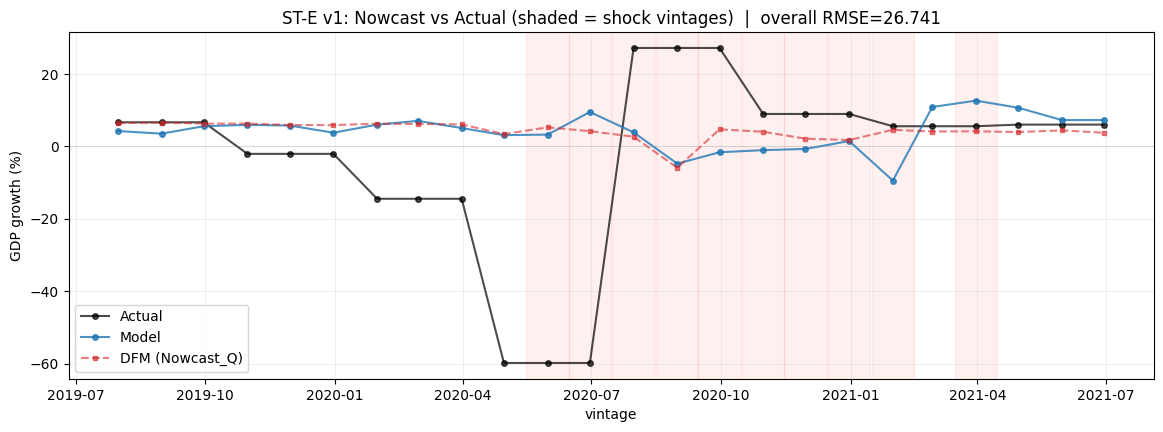

In [27]:
ax = plot_nowcasts(ste_merged, dfm_df=dfm_in_range, title=
    f"ST-E v1: Nowcast vs Actual (shaded = shock vintages)  |  overall RMSE={ste_rmse['ST-E/overall']:.3f}")
plt.savefig(OUTPUT_DIR / "ste_v1_nowcast_timeseries.png", dpi=110, bbox_inches="tight"); plt.show()

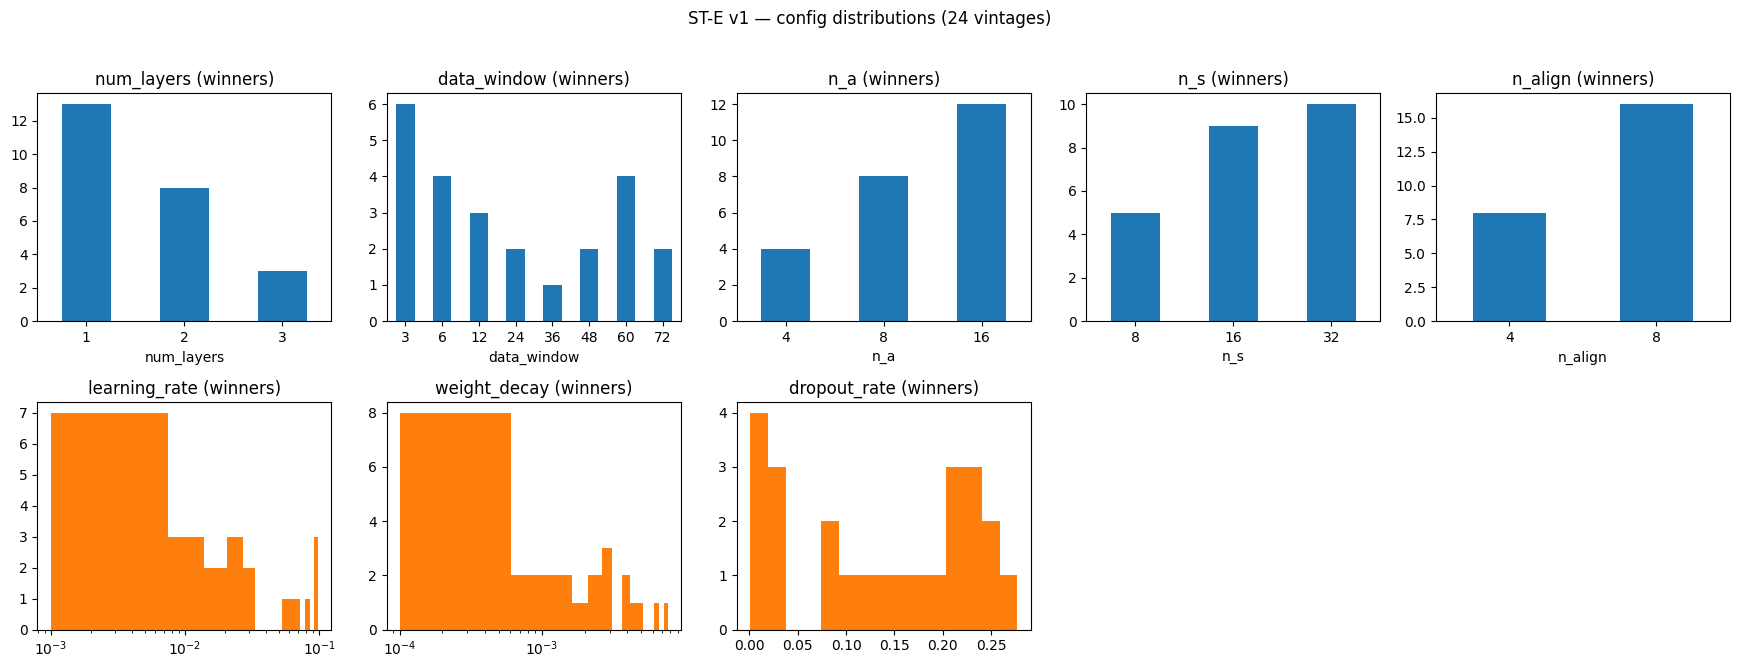

In [18]:
plot_config_distributions(ste_best, "ST-E v1").savefig(
    OUTPUT_DIR / "ste_v1_config_dist.png", dpi=110, bbox_inches="tight")
plt.show()

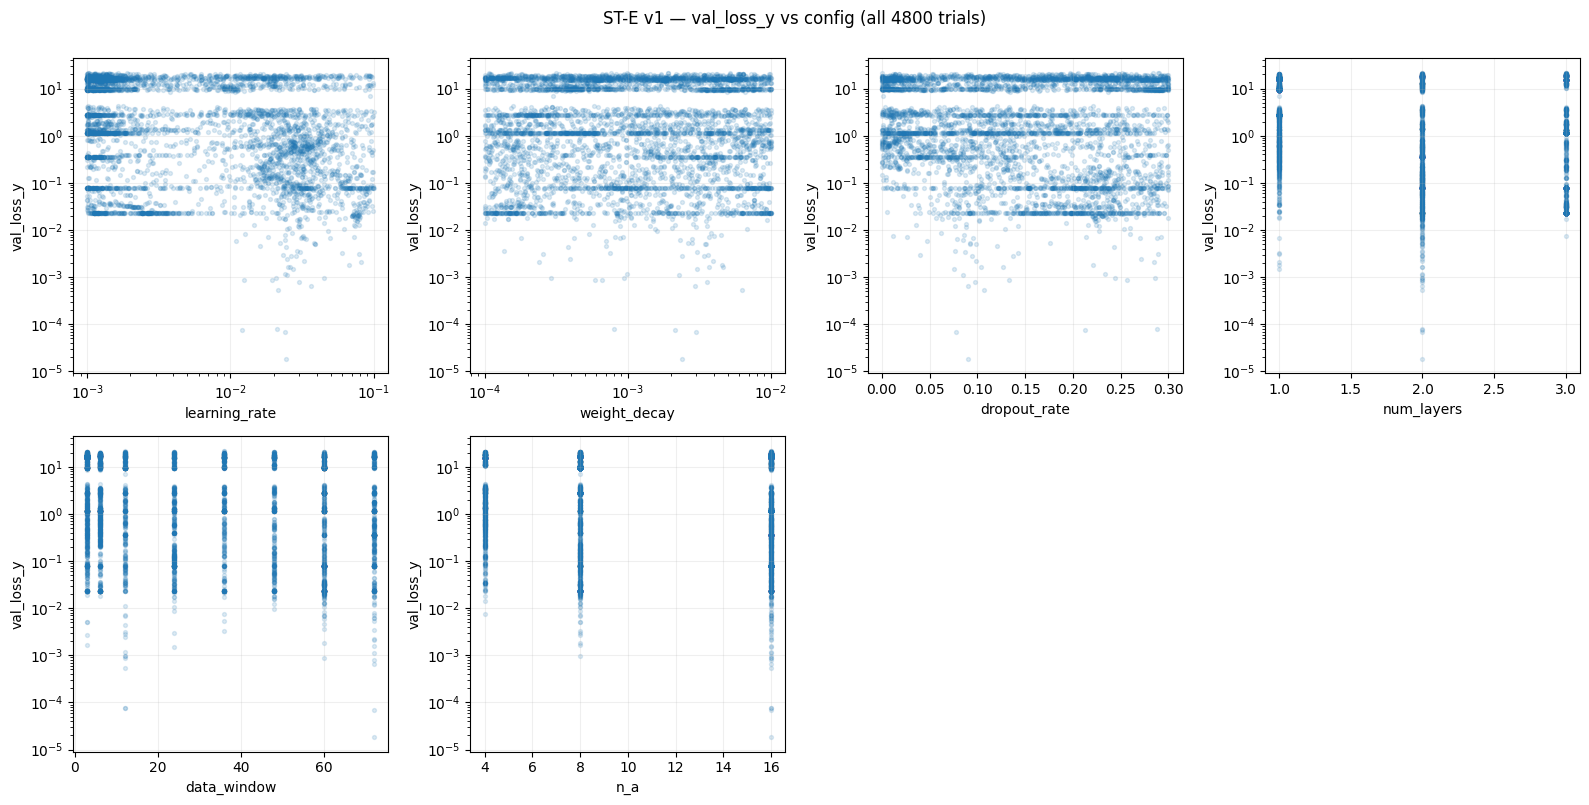

In [19]:
ste_all = load_all_trials("singletask_nobiasEv1", task="singletask", vintages=VINTAGES_V1)
plot_scatter_grid(ste_all, "ST-E v1").savefig(
    OUTPUT_DIR / "ste_v1_scatter.png", dpi=110, bbox_inches="tight")
plt.show()

## MT-E autoregressive v1

In [20]:
mte_best = load_best_configs("multitask_nobiasEv1", task="multitask", vintages=VINTAGES_V1)
mte_best.sort_values("val_loss_y")[["vintage_str", "val_loss_y", "learning_rate", "weight_decay",
    "alpha", "num_layers", "data_window", "n_a", "n_s", "n_align", "dropout_rate"]].round(4)

,vintage_str,val_loss_y,learning_rate,weight_decay,alpha,num_layers,data_window,n_a,n_s,n_align,dropout_rate
23,2021-06,0.0310,0.0016,0.0001,2.0808,2,6,8,16,4,0.2411
2,2019-09,0.0365,0.0763,0.0049,0.0103,1,24,16,16,8,0.0777
22,2021-05,0.0396,0.0583,0.0008,10.6849,3,6,16,8,4,0.2903
1,2019-08,0.0705,0.0431,0.0096,61.1919,2,24,8,32,8,0.1321
3,2019-10,0.1397,0.0714,0.0011,0.0122,2,48,8,32,4,0.0654
5,2019-12,0.1540,0.0158,0.0051,1.1631,2,36,8,32,4,0.2905
9,2020-04,0.1735,0.0171,0.0016,827.6296,1,3,16,32,8,0.0880
7,2020-02,0.2274,0.0374,0.0028,85.0485,3,12,8,32,8,0.0477
6,2020-01,0.2388,0.0918,0.0037,0.3433,3,24,8,16,4,0.2529
4,2019-11,0.4292,0.0961,0.0082,2.2897,2,24,8,16,8,0.0053


In [21]:
mte_nowcasts = compute_nowcasts(mte_best, task="multitask", cache_key="mte_v1")
mte_rmse, mte_merged = rmse_by_regime(mte_nowcasts, dfm, label="MT-E")
pd.Series({**mte_rmse, **ste_rmse, **dfm_rmse}).round(3)

MT-E/overall    26.133
MT-E/normal     20.879
MT-E/shock      32.074
ST-E/overall    26.741
ST-E/normal     19.740
ST-E/shock      34.215
DFM/overall     27.413
DFM/normal      20.343
DFM/shock       35.201
dtype: float64

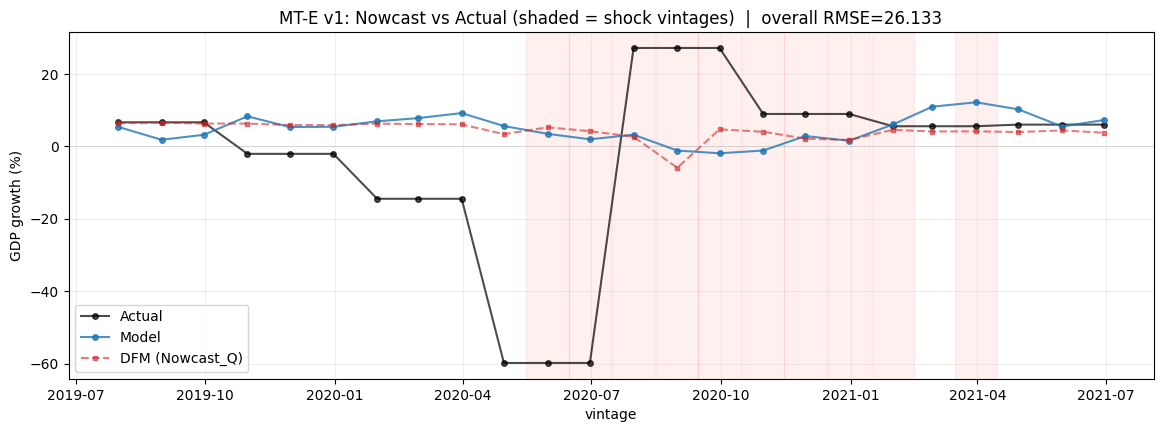

In [28]:
ax = plot_nowcasts(mte_merged, dfm_df=dfm_in_range, title=
    f"MT-E v1: Nowcast vs Actual (shaded = shock vintages)  |  overall RMSE={mte_rmse['MT-E/overall']:.3f}")
plt.savefig(OUTPUT_DIR / "mte_v1_nowcast_timeseries.png", dpi=110, bbox_inches="tight"); plt.show()

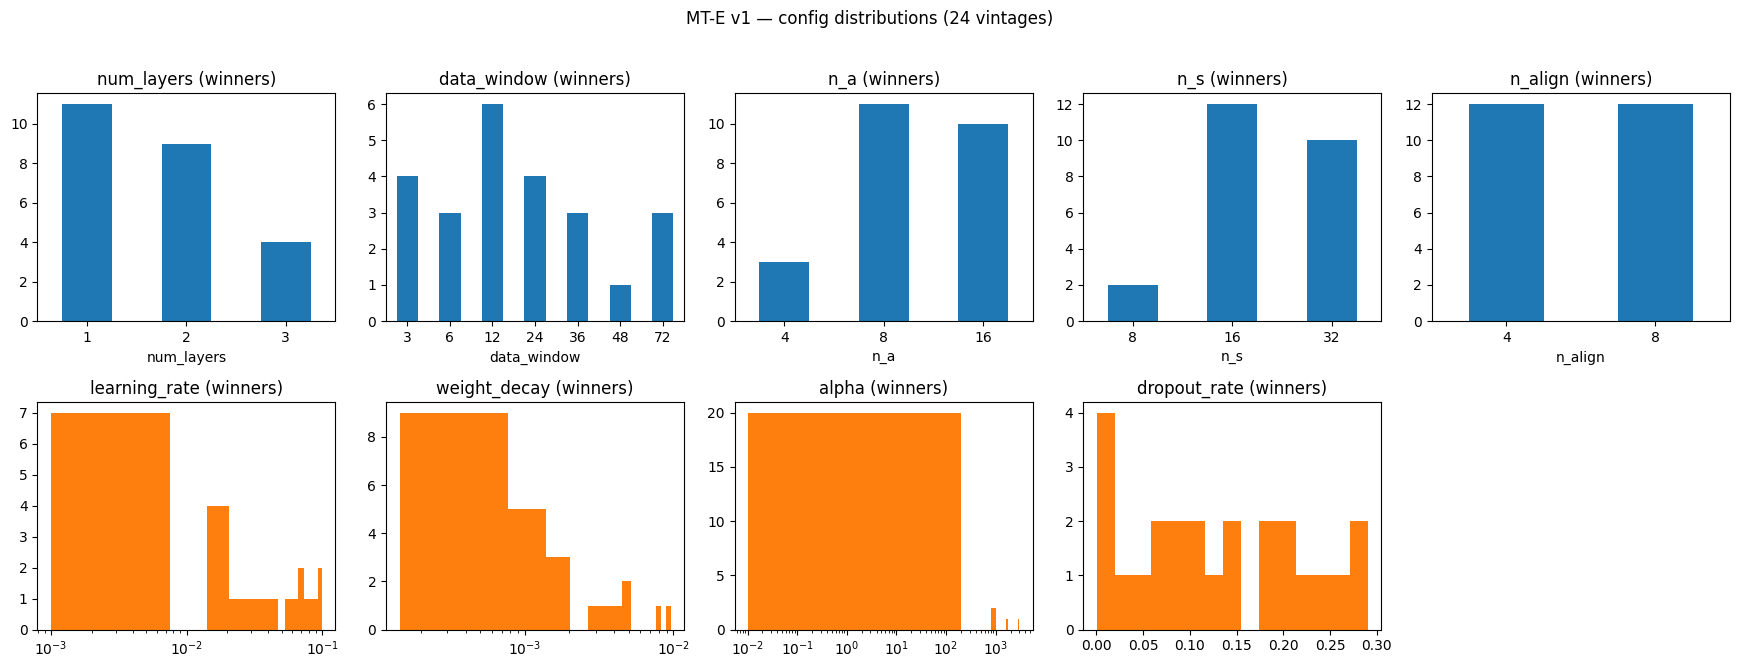

In [23]:
plot_config_distributions(mte_best, "MT-E v1").savefig(
    OUTPUT_DIR / "mte_v1_config_dist.png", dpi=110, bbox_inches="tight")
plt.show()

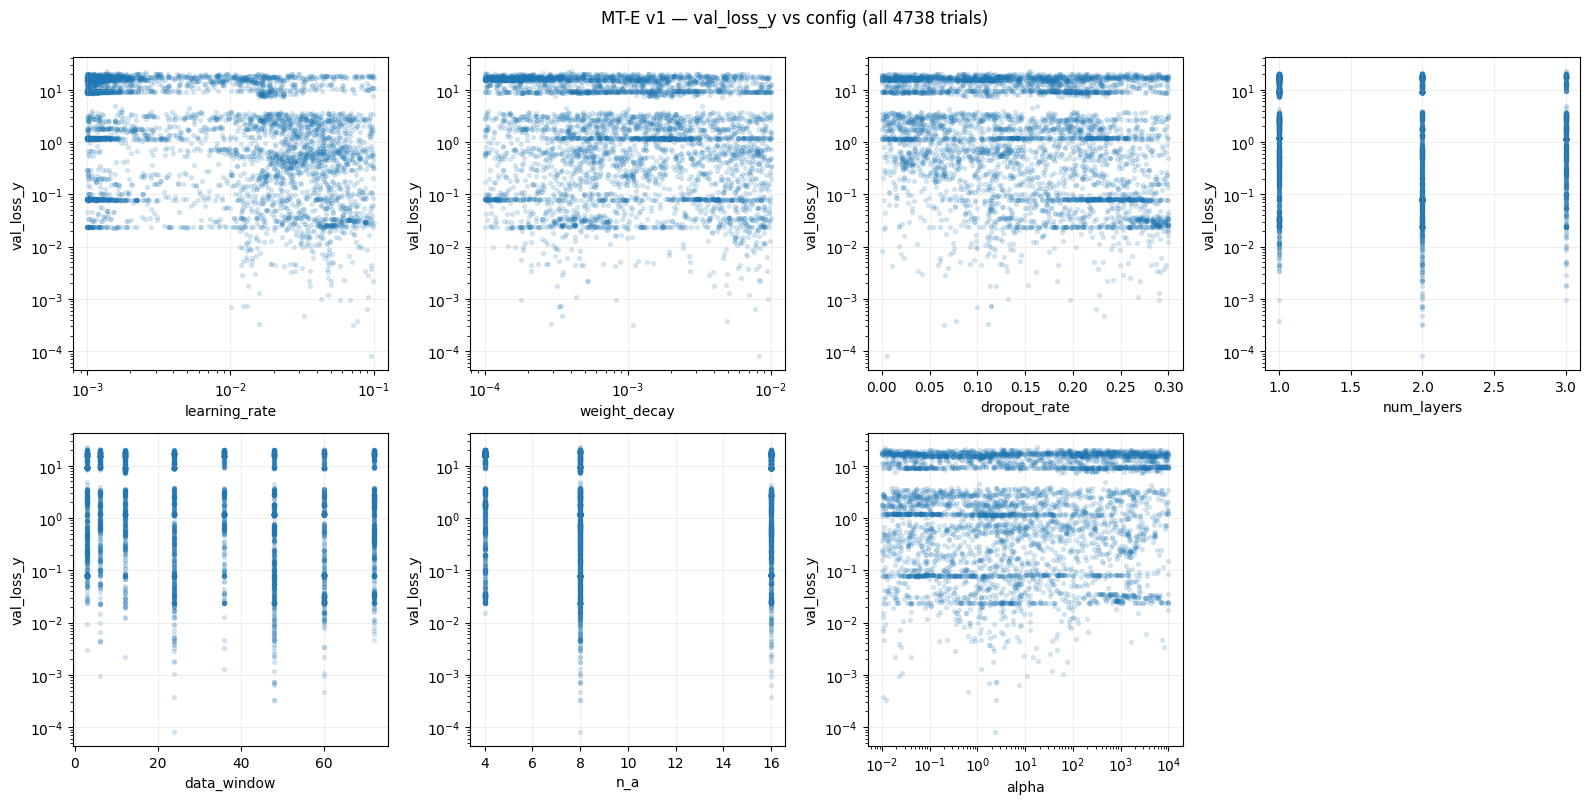

In [24]:
mte_all = load_all_trials("multitask_nobiasEv1", task="multitask", vintages=VINTAGES_V1)
plot_scatter_grid(mte_all, "MT-E v1").savefig(
    OUTPUT_DIR / "mte_v1_scatter.png", dpi=110, bbox_inches="tight")
plt.show()

## ST vs MT side-by-side

One table. Rows = RMSE metrics, columns = models. Lower is better.

In [31]:
rows = {}
for key, val in {**ste_rmse, **mte_rmse, **dfm_rmse}.items():
    model, regime = key.split("/")
    rows.setdefault(regime, {})[model] = val
comp_df = pd.DataFrame(rows).T[["ST-E", "MT-E", "DFM"]]
comp_df.round(3)

,ST-E,MT-E,DFM
overall,26.741,26.133,27.413
normal,19.740,20.879,20.343
shock,34.215,32.074,35.201


## Pre-attention variants (ST)

Runs in progress. Cells below will execute once the runs complete. Same structure as the ST-E / MT-E blocks above but with different experiment subdirs.

In [32]:
# ST preattn (unidir)
try:
    ste_pa_best = load_best_configs("singletask_nobiasEpreattn_v1", task="singletask", vintages=VINTAGES_V1)
    ste_pa_nowcasts = compute_nowcasts(ste_pa_best, task="singletask", cache_key="ste_pa_v1")
    ste_pa_rmse, ste_pa_merged = rmse_by_regime(ste_pa_nowcasts, dfm, label="ST-E-preattn")
    print(ste_pa_rmse)
except Exception as e:
    print(f"not ready: {e}")

{'ST-E-preattn/overall': np.float64(26.575928328526395), 'ST-E-preattn/normal': np.float64(19.94457929607981), 'ST-E-preattn/shock': np.float64(33.736792660809805)}


In [39]:
# ST preattn (bidir)
try:
    ste_pab_best = load_best_configs("singletask_nobiasEpreattn_bidir_v1", task="singletask", vintages=VINTAGES_V1)
    ste_pab_nowcasts = compute_nowcasts(ste_pab_best, task="singletask", cache_key="ste_pab_v1")
    ste_pab_rmse, ste_pab_merged = rmse_by_regime(ste_pab_nowcasts, dfm, label="ST-E-preattn-bidir")
    print(ste_pab_rmse)
except Exception as e:
    print(f"not ready: {e}")

{'ST-E-preattn-bidir/overall': np.float64(27.160251845989492), 'ST-E-preattn-bidir/normal': np.float64(20.83687639895168), 'ST-E-preattn-bidir/shock': np.float64(34.09669613787993)}


In [43]:
# MT preattn (unidir)
try:
    mte_pa_best = load_best_configs("multitask_nobiasEpreattn_v1", task="multitask", vintages=VINTAGES_V1)
    mte_pa_nowcasts = compute_nowcasts(mte_pa_best, task="multitask", cache_key="mte_pa_v1")
    mte_pa_rmse, mte_pa_merged = rmse_by_regime(mte_pa_nowcasts, dfm, label="MT-E-preattn")
    print(mte_pa_rmse)
except Exception as e:
    print(f"not ready: {e}")

{'MT-E-preattn/overall': np.float64(26.217305706767668), 'MT-E-preattn/normal': np.float64(21.240256958280803), 'MT-E-preattn/shock': np.float64(31.906506586239672)}


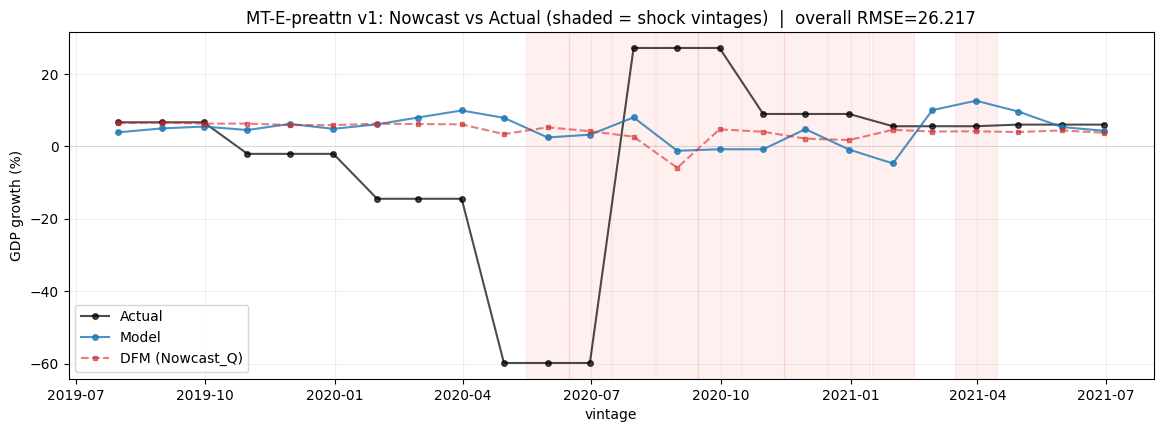

In [46]:
ax = plot_nowcasts(mte_pa_merged, dfm_df=dfm_in_range, title=
    f"MT-E-preattn v1: Nowcast vs Actual (shaded = shock vintages)  |  overall RMSE={mte_pa_rmse['MT-E-preattn/overall']:.3f}")
# plt.savefig(OUTPUT_DIR / "mte_pa_v1_nowcast_timeseries.png", dpi=110, bbox_inches="tight"); plt.show()

In [44]:
# MT preattn (bidir)
try:
    mte_pab_best = load_best_configs("multitask_nobiasEpreattn_bidir_v1", task="multitask", vintages=VINTAGES_V1)
    mte_pab_nowcasts = compute_nowcasts(mte_pab_best, task="multitask", cache_key="mte_pab_v1")
    mte_pab_rmse, mte_pab_merged = rmse_by_regime(mte_pab_nowcasts, dfm, label="MT-E-preattn-bidir")
    print(mte_pab_rmse)
except Exception as e:
    print(f"not ready: {e}")

{'MT-E-preattn-bidir/overall': np.float64(26.971004911135093), 'MT-E-preattn-bidir/normal': np.float64(21.70365932363315), 'MT-E-preattn-bidir/shock': np.float64(32.9602168522702)}


In [45]:
# Full comparison table (fills in whatever runs have completed)
all_rmse = {**dfm_rmse, **ste_rmse, **mte_rmse}
for name in ["ste_pa_rmse", "ste_pab_rmse", "mte_pa_rmse", "mte_pab_rmse"]:
    if name in globals():
        all_rmse.update(globals()[name])

rows = {}
for key, val in all_rmse.items():
    model, regime = key.split("/")
    rows.setdefault(regime, {})[model] = val
pd.DataFrame(rows).T.round(3)

,DFM,ST-E,MT-E,ST-E-preattn,ST-E-preattn-bidir,MT-E-preattn,MT-E-preattn-bidir
overall,27.413,26.741,26.133,26.576,27.160,26.217,26.971
normal,20.343,19.740,20.879,19.945,20.837,21.240,21.704
shock,35.201,34.215,32.074,33.737,34.097,31.907,32.960
